## ДЗ №5 Бустинги. Предсказание цены квартир по табличным данным.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
sns.set(style='darkgrid')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, LinearRegression, Lasso, PoissonRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
from statistics import mean
from sklearn.decomposition import PCA
from scipy.stats import norm
from scipy import stats
from scipy.stats import pearsonr
import xgboost as xgb

Для начала посмотрим на данные.

In [ ]:
df = pd.read_csv('train.csv')
df

,id,date,street_id,build_tech,floor,area,rooms,balcon,metro_dist,g_lift,...,kw5,kw6,kw7,kw8,kw9,kw10,kw11,kw12,kw13,price
0,0,2011-1,560,NaN,2,59,3,0,30.0,1.0,...,0,0,0,0,0,0,0,0,0,4510000
1,1,2011-1,667,NaN,10,50,2,1,25.0,NaN,...,0,0,0,0,0,0,0,0,0,13231000
2,2,2011-1,90,0.0,1,48,2,0,25.0,0.0,...,0,0,0,0,0,0,0,0,0,2008000
3,3,2011-1,94,1.0,3,62,3,1,30.0,NaN,...,0,0,0,0,0,0,0,0,0,12680000
4,4,2011-1,232,0.0,3,60,3,0,25.0,NaN,...,0,0,0,0,0,0,0,0,0,3335000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,2012-3,401,0.0,5,30,1,0,30.0,NaN,...,0,0,0,0,0,0,0,0,0,1697000
99996,99996,2012-3,59,0.0,4,34,1,0,30.0,NaN,...,0,0,0,0,0,0,0,0,0,3620000
99997,99997,2012-3,253,NaN,3,52,2,0,5.0,NaN,...,0,0,0,0,0,0,0,0,0,6712000
99998,99998,2012-3,305,1.0,3,181,5,1,5.0,NaN,...,0,0,0,0,0,0,0,0,0,20835000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          100000 non-null  int64  
 1   date        100000 non-null  object 
 2   street_id   100000 non-null  int64  
 3   build_tech  70265 non-null   float64
 4   floor       100000 non-null  int64  
 5   area        100000 non-null  int64  
 6   rooms       100000 non-null  int64  
 7   balcon      100000 non-null  int64  
 8   metro_dist  95104 non-null   float64
 9   g_lift      70008 non-null   float64
 10  n_photos    100000 non-null  int64  
 11  kw1         100000 non-null  int64  
 12  kw2         100000 non-null  int64  
 13  kw3         100000 non-null  int64  
 14  kw4         100000 non-null  int64  
 15  kw5         100000 non-null  int64  
 16  kw6         100000 non-null  int64  
 17  kw7         100000 non-null  int64  
 18  kw8         100000 non-null  int64  
 19  kw9

Видно, что столбцы 'metro_dist', 'g_lift', 'build_tech' имеют немало пустых значений. Нужно будет их заполнить, но чуть похже это сделаем. Сначала убираем столбец 'id', так как он не имеет смысла для обучения (от порядкового номера целевая переменная никак не зависит). А переобучить модель может запросто.

In [ ]:
df.drop('id', axis = 1, inplace = True)

Посмотрим на распределение значений целевой переменной 'price'

<ipython-input-213-455f8f30df47>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'] , fit=norm);


Для нормального распределения (чёрный цвет):
mu = 5138395.94 и sigma = 4187447.92



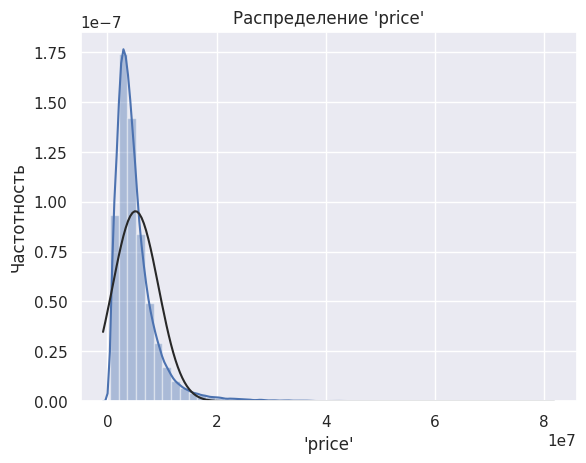

<Figure size 640x480 with 0 Axes>

In [ ]:
sns.distplot(df['price'] , fit=norm);
(mu, sigma) = norm.fit(df['price'])
print('Для нормального распределения (чёрный цвет):\nmu = {:.2f} и sigma = {:.2f}\n'.format(mu, sigma))
plt.xlabel('\'price\'')
plt.ylabel('Частотность')
plt.title('Распределение \'price\'')
fig = plt.figure()
plt.show()

Видно, что распределение цены далеко от нормального распределения. Скорее это распределение с длинным правым хвостом, когда слишком дорогие квартиры по отдельности не особо популярны, но в совокупности они имеют такой вес, что ими пренебрегать нельзя. Напрямую обучать такие данные не эффективно, если функция потерь чувствительна к выбросам.

Для обучения линейных моделей хорошо было бы найти признаки, наиболее скоррелированные с целевой переменной. Перед этим сделаем минимальные манипуляции с данными.

In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,100000,18,2011-4,5671,NaN,NaN,NaN,NaN,NaN,NaN,NaN
street_id,100000.0,NaN,NaN,NaN,334.47929,194.004755,0.0,167.0,334.0,501.0,671.0
build_tech,70265.0,NaN,NaN,NaN,0.529837,0.573645,0.0,0.0,0.0,1.0,2.0
floor,100000.0,NaN,NaN,NaN,5.26768,3.905558,1.0,2.0,4.0,7.0,25.0
area,100000.0,NaN,NaN,NaN,52.25343,17.7925,29.0,40.0,52.0,60.0,217.0
rooms,100000.0,NaN,NaN,NaN,2.11868,0.829688,1.0,1.0,2.0,3.0,6.0
balcon,100000.0,NaN,NaN,NaN,0.39674,0.547632,0.0,0.0,0.0,1.0,2.0
metro_dist,95104.0,NaN,NaN,NaN,22.154431,8.286241,0.0,15.0,25.0,30.0,30.0
g_lift,70008.0,NaN,NaN,NaN,0.500986,0.500003,0.0,0.0,1.0,1.0,1.0
n_photos,100000.0,NaN,NaN,NaN,2.47091,1.944981,0.0,1.0,2.0,4.0,11.0


 Обращаем внимание, что есть один нечисловой признак. Это дата, и скорее всего дата постройки. Её легко перевести в числовой признак. Раз в дате указан только год и месяц, то можно получить однозначных хеш даты в виде общего количества месяцев (год*12 + месяц). Это можно представлять как числовой тип. Правда месяцы нужно будет нумеровать с нуля, поэтому при получении хеша, от месяца надо отнять единицу.

In [ ]:
df_hashed = df
dateHashArr = np.zeros(shape=len(df['date']), dtype=int)
for i in range(0, len(df['date'])):
  strDate = df['date'][i]
  year = int(strDate.split('-')[0])
  month = int(strDate.split('-')[1]) - 1 #месяцы нумеруем с 0
  dateHashArr[i] = 12*year + month
df_hashed['date'] = dateHashArr

Заполним пустые значения в столбцах 'metro_dist', 'g_lift', 'build_tech' средними значениями в соответствующем столбце.

In [ ]:
df_filled = df_hashed
df_filled['metro_dist'] = df_hashed['metro_dist'].fillna(df_hashed['metro_dist'].mean())
df_filled['build_tech'] = df_hashed['build_tech'].fillna(1)
df_filled['g_lift'] = df_hashed['g_lift'].fillna(0.5)

Посмотрим теперь, как выглядит фрейм с хешированными значениями даты. Видно, что поле даты постройки стало числовым значением.

In [ ]:
df_filled.head()

,date,street_id,build_tech,floor,area,rooms,balcon,metro_dist,g_lift,n_photos,...,kw5,kw6,kw7,kw8,kw9,kw10,kw11,kw12,kw13,price
0,24132,560,1.0,2,59,3,0,30.0,1.0,5,...,0,0,0,0,0,0,0,0,0,4510000
1,24132,667,1.0,10,50,2,1,25.0,0.5,1,...,0,0,0,0,0,0,0,0,0,13231000
2,24132,90,0.0,1,48,2,0,25.0,0.0,1,...,0,0,0,0,0,0,0,0,0,2008000
3,24132,94,1.0,3,62,3,1,30.0,0.5,3,...,0,0,0,0,0,0,0,0,0,12680000
4,24132,232,0.0,3,60,3,0,25.0,0.5,3,...,0,0,0,0,0,0,0,0,0,3335000


Далее нужно посмотреть на то, как признаки коррелируют с целевой переменной.

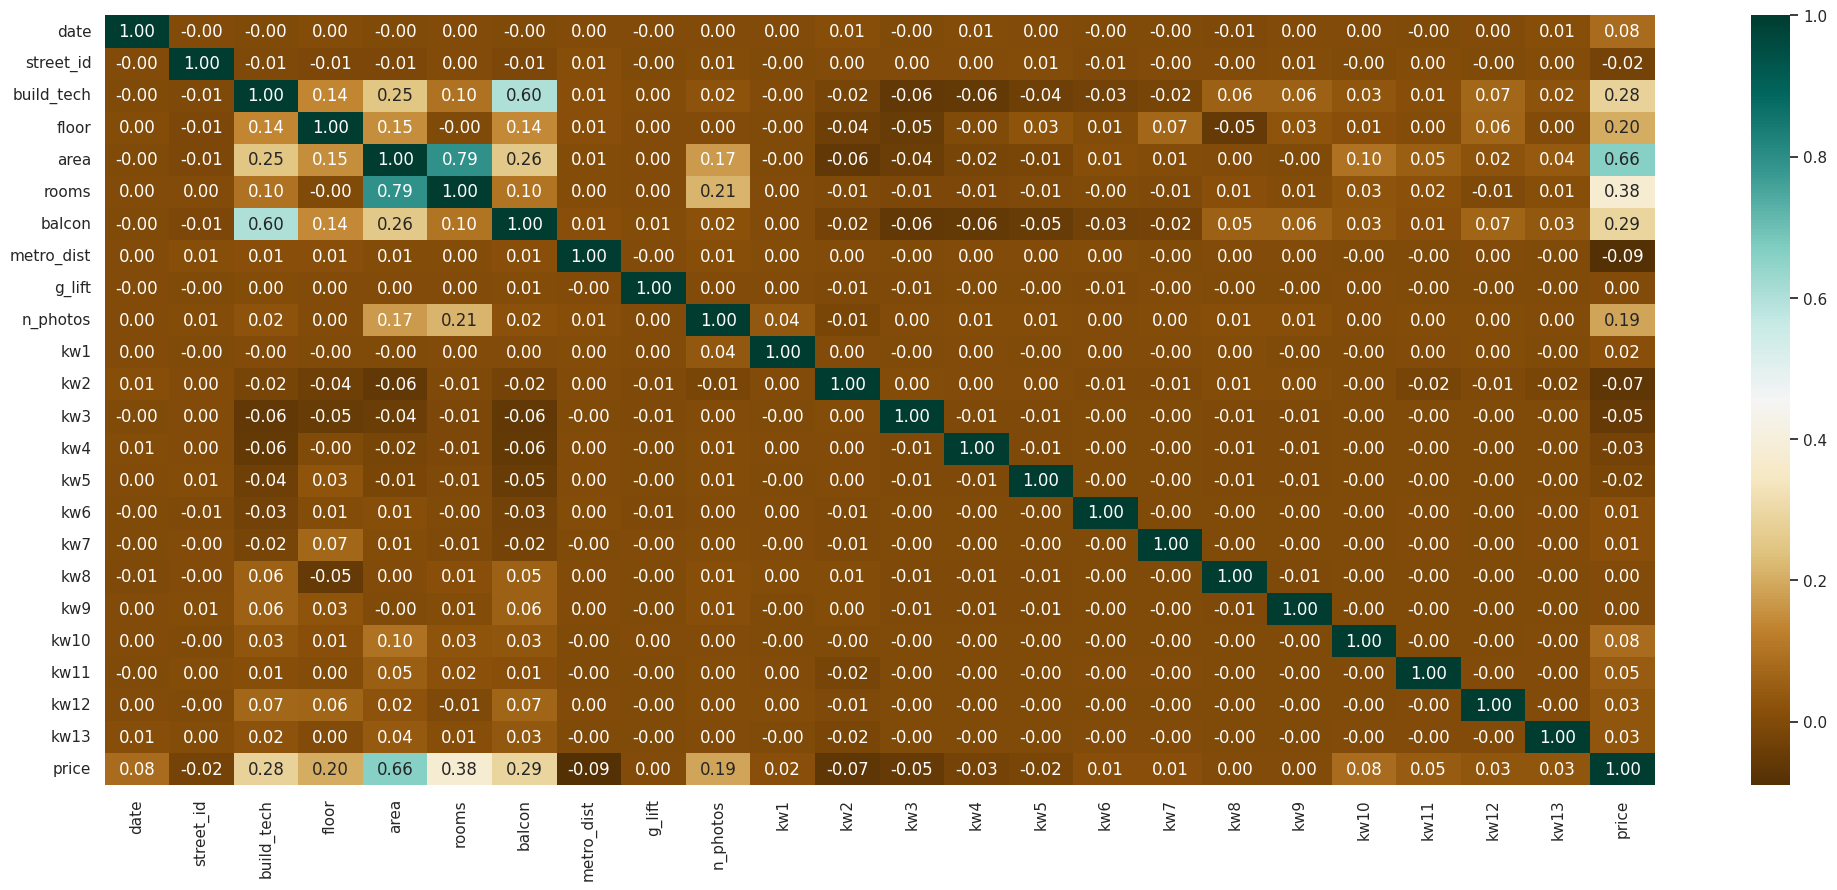

In [ ]:
plt.figure(figsize=(25, 10))
sns.heatmap(df_filled.corr(), annot=True, fmt = '.2f', cmap='BrBG')
plt.show()

По корреляционной матрице выше видно, что признак 'area' довольно неплохо коррелирует с целевой переменной 'price'.

Стоит отметить, что признаки: 'build_tech', 'floor', 'rooms', 'balcon', 'n_photos' в более слабой степени коррелируют с 'price'. Причём большинство из них примерно в равных степенях коррелируют, что с 'area', что с 'price'.

Только признак 'rooms' выделяется более сильной корреляцией с 'area' по сравнению с 'price'.

Из этого всего можно сделать вывод, что пристальное внимание нужно уделять признаку 'area'. Остальные конечно тоже важны для предсказания цены, но не так сильно.

Далее нужно избавиться от длинного правого хвоста в распределении целевой переменной 'price'. Прогогарифмируем её значения:

In [ ]:
df_log = df_filled
df_log['price'] = np.log1p(df_filled['price'])

<ipython-input-220-0000c71052ff>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_log['price'], fit=norm);


Для нормального распределения (чёрный цвет):
mu = 15.22 и sigma = 0.68



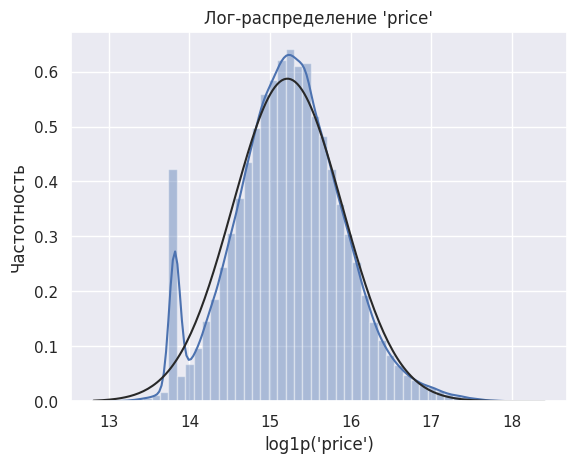

<Figure size 640x480 with 0 Axes>

In [ ]:
sns.distplot(df_log['price'], fit=norm);
(mu, sigma) = norm.fit(df_log['price'])
print('Для нормального распределения (чёрный цвет):\nmu = {:.2f} и sigma = {:.2f}\n'.format(mu, sigma))
plt.xlabel('log1p(\'price\')')
plt.ylabel('Частотность')
plt.title('Лог-распределение \'price\'')
fig = plt.figure()
plt.show()

На графике выше видно, что получилось "почти" нормальное распределение. Но всё же, это ещё не совсем нормальное распределение, так как слева от шляпы есть выступ, который будет портить нам всё обучение.

Путём подбора я определил, что достаточно убрать такие строки из фрейма, у которых значения целевой переменной лежат в диапазоне 13.81 < log1p('price') < 13.82

In [ ]:
df_log = df_log.drop(df_log[(df_log['price'] > 13.81) & (df_log['price'] < 13.82)].index).reset_index(drop=True)

<ipython-input-222-3d16c7d83d7f>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_log['price'], fit=norm);


Для нормального распределения (чёрный цвет):
mu = 15.28 и sigma = 0.63



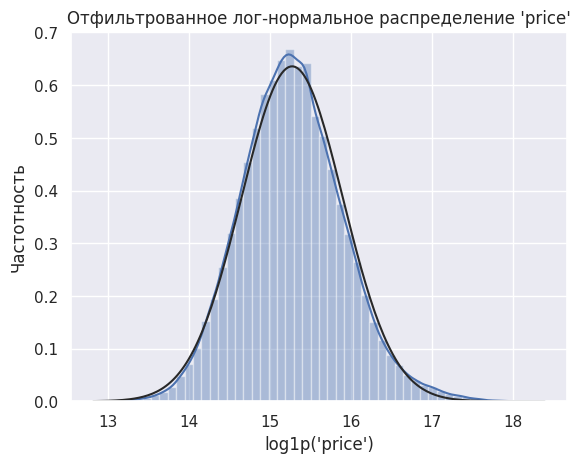

<Figure size 640x480 with 0 Axes>

In [ ]:
sns.distplot(df_log['price'], fit=norm);
(mu, sigma) = norm.fit(df_log['price'])
print('Для нормального распределения (чёрный цвет):\nmu = {:.2f} и sigma = {:.2f}\n'.format(mu, sigma))
plt.xlabel('log1p(\'price\')')
plt.ylabel('Частотность')
plt.title('Отфильтрованное лог-нормальное распределение \'price\'')
fig = plt.figure()
plt.show()

После отсеивания лишних строк датафрейма, судя по графику выше, получилось распределение, близкое к нормальному.

In [ ]:
x_all = df_log.drop('price', axis=1)
y_all = df_log['price']
x_train, x_test, y_train, y_test = train_test_split(x_all, y_all, test_size=0.4, random_state=42)

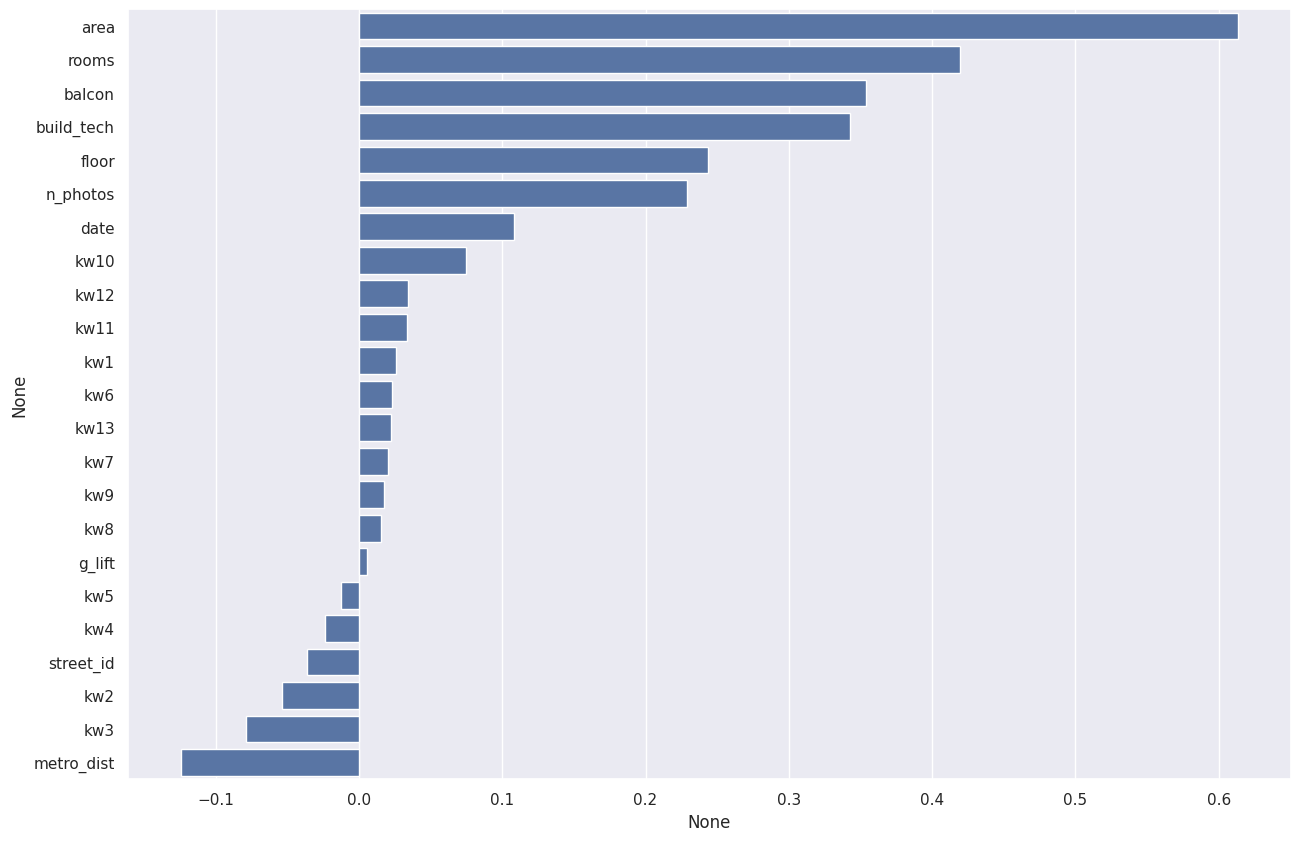

In [ ]:
corrs = x_train.corrwith(y_train).sort_values(ascending=False)
sbPlot = sns.barplot(x=corrs, y=corrs.index)
sbPlot.figure.set_size_inches(15, 10)

Далее интересно посмотреть, как распределены значения главного признака 'area'.

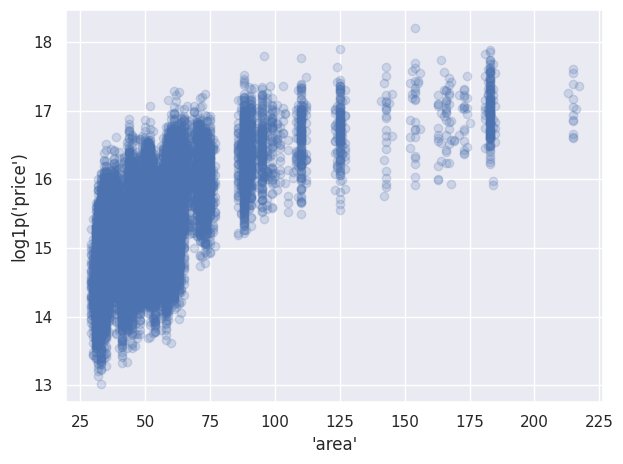

In [ ]:
fig, ax = plt.subplots()
ax.scatter(x_test['area'], y_test, alpha=0.2)
ax.set_xlabel('\'area\'')
ax.set_ylabel('log1p(\'price\')')
plt.tight_layout()

Лично мне это распределение напоминает нормальное распределение с обратным средним. Как правило, чтобы его приблизить к нормальному распределению, нужно все значения 'area' прологарифмировать, что будет сделано ниже:

In [ ]:
x_train['area'] = np.log1p(x_train['area'])
x_test['area'] = np.log1p(x_test['area'])

Посмотрим, что получится на этот раз:

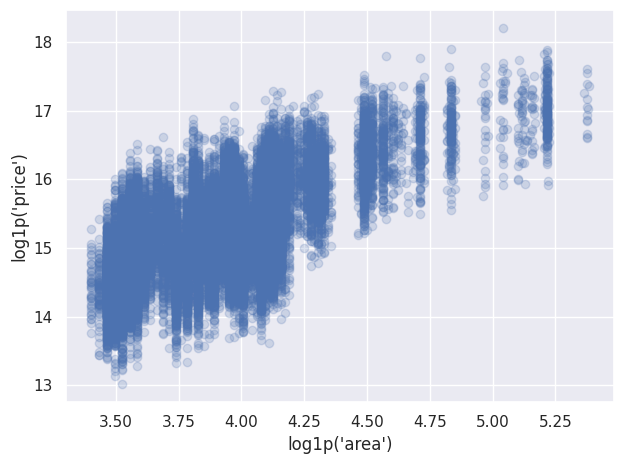

In [ ]:
fig, ax = plt.subplots()
ax.scatter(x_test['area'], y_test, alpha=0.2)
ax.set_xlabel('log1p(\'area\')')
ax.set_ylabel('log1p(\'price\')')
plt.tight_layout()

А это уже похоже на нормальное распределение, через которую удобно можно провести линию регрессии. Далее стоит попробовать различные регрессионные модели.

In [ ]:
scaler = MinMaxScaler()
x_train_arr = scaler.fit_transform(x_train.values)
x_train_std = pd.DataFrame(x_train_arr, index = x_train.index, columns = x_train.columns)
#x_train_std['area'] = x_train['area']
x_test_arr = scaler.fit_transform(x_test.values)
x_test_std = pd.DataFrame(x_test_arr, index = x_test.index, columns = x_test.columns)
#x_test_std['area'] = x_test['area']
x_test_std

,date,street_id,build_tech,floor,area,rooms,balcon,metro_dist,g_lift,n_photos,...,kw4,kw5,kw6,kw7,kw8,kw9,kw10,kw11,kw12,kw13
43690,0.217391,0.725782,0.5,0.166667,0.267548,0.2,0.0,1.000000,0.5,0.090909,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
70794,0.913043,0.315946,0.5,0.125000,0.349492,0.4,0.0,0.500000,0.5,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
70747,0.913043,0.988077,0.0,0.041667,0.119190,0.0,0.0,0.666667,0.0,0.090909,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25271,0.043478,0.786885,0.5,0.208333,0.277339,0.0,0.5,0.666667,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
22529,0.043478,0.825633,0.5,0.125000,0.286944,0.2,0.5,0.333333,0.5,0.363636,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17281,0.478261,0.928465,0.5,0.083333,0.286944,0.2,0.0,1.000000,1.0,0.545455,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18276,0.478261,0.901639,0.5,0.125000,0.357827,0.4,0.5,0.166667,0.0,0.363636,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11376,0.434783,0.081967,0.0,0.166667,0.063109,0.0,0.0,1.000000,0.5,0.181818,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38162,0.173913,0.967213,0.5,0.333333,0.091928,0.0,0.5,0.166667,0.0,0.181818,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
model = Ridge()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
y_train_pred = model.predict(x_train)
print("Test MAE = %.4f" % mean_absolute_error(y_test, y_pred))
print("Train MAE = %.4f" % mean_absolute_error(y_train, y_train_pred))
#print("Test MAE = %.4f" % mean_absolute_error(np.expm1(y_test), np.expm1(y_pred)))
#print("Train MAE = %.4f" % mean_absolute_error(np.expm1(y_train), np.expm1(y_train_pred)))

Test MAE = 0.3356
Train MAE = 0.3337


In [ ]:
model1 = LinearRegression()
model1.fit(x_train, y_train)
y_pred1 = model1.predict(x_test)
y_train_pred1 = model1.predict(x_train)
print("Test MAE = %.4f" % mean_absolute_error(y_test, y_pred1))
print("Train MAE = %.4f" % mean_absolute_error(y_train, y_train_pred1))
#print("Test MAE = %.4f" % mean_absolute_error(np.expm1(y_test), np.expm1(y_pred1)))
#print("Train MAE = %.4f" % mean_absolute_error(np.expm1(y_train), np.expm1(y_train_pred1)))

Test MAE = 0.3356
Train MAE = 0.3337


In [ ]:
regressor = RandomForestRegressor(max_depth = 9, random_state=42)
regressor.fit(x_train, y_train)
y_pred2 = regressor.predict(x_test)
y_train_pred2 = regressor.predict(x_train)
print("Test MAE = %.4f" % mean_absolute_error(y_test, y_pred2))
print("Train MAE = %.4f" % mean_absolute_error(y_train, y_train_pred2))
#print("Test MAE = %.4f" % mean_absolute_error(np.expm1(y_test), np.expm1(y_pred2)))
#print("Train MAE = %.4f" % mean_absolute_error(np.expm1(y_train), np.expm1(y_train_pred2)))

Test MAE = 0.3214
Train MAE = 0.3102


In [ ]:
model_xgb = xgb.XGBRegressor(colsample_bytree=0.2, gamma=0.0,
                             learning_rate=0.04, max_depth=6,
                             min_child_weight=1.5, n_estimators=3600,
                             reg_alpha=0.9, reg_lambda=0.6,
                             subsample=0.2,seed=42, silent=1,
                             random_state = 42)
model_xgb.fit(x_train, y_train)
xgb_test_pred = model_xgb.predict(x_test)
xgb_train_pred = model_xgb.predict(x_train)
print("Test MAE = %.4f" % mean_absolute_error(y_test, xgb_test_pred))
print("Train MAE = %.4f" % mean_absolute_error(y_train, xgb_train_pred))
#print("Test MAE = %.4f" % mean_absolute_error(np.expm1(y_test), np.expm1(xgb_test_pred)))
#print("Train MAE = %.4f" % mean_absolute_error(np.expm1(y_train), np.expm1(xgb_train_pred)))

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [19:26:59] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "silent" } are not used.

  warnings.warn(smsg, UserWarning)


Test MAE = 0.2654
Train MAE = 0.2506


Подготовка тестовой выборки

In [ ]:
dfTest = pd.read_csv('test.csv')
dfTest['metro_dist'] = dfTest['metro_dist'].fillna(dfTest['metro_dist'].mean())
dfTest['g_lift'] = dfTest['g_lift'].fillna(dfTest['g_lift'].mean()) #можно попробовать заполнить средним значением
dfTest['build_tech'] = dfTest['build_tech'].fillna(0.5)
dfTest_new = dfTest
dateHashArr = np.zeros(shape=len(dfTest['date']), dtype=int)
for i in range(0, len(dfTest['date'])):
  strng = dfTest['date'][i]
  year = int(strng.split('-')[0])
  month = int(strng.split('-')[1]) - 1 #месяцы нумеруем с 0
  dateHashArr[i] = 12*year + month
dfTest_new['date'] = dateHashArr
dfTest_new


,id,date,street_id,build_tech,floor,area,rooms,balcon,metro_dist,g_lift,...,kw4,kw5,kw6,kw7,kw8,kw9,kw10,kw11,kw12,kw13
0,100000,24146,459,0.5,1,60,3,1,30.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0
1,100001,24146,344,1.0,10,52,2,1,22.081353,0.499701,...,0,0,0,0,0,0,0,0,0,0
2,100002,24146,585,0.0,4,54,3,0,30.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0
3,100003,24146,494,0.5,2,52,2,1,25.000000,1.000000,...,0,0,0,0,0,0,0,0,0,0
4,100004,24146,622,1.0,9,60,3,1,15.000000,0.499701,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,199995,24164,613,1.0,2,34,1,1,25.000000,0.499701,...,0,0,0,0,0,0,0,0,0,0
99996,199996,24164,167,1.0,10,61,3,1,30.000000,0.499701,...,0,0,0,0,0,0,0,0,0,0
99997,199997,24164,391,1.0,9,34,1,1,30.000000,0.499701,...,0,0,0,0,0,0,0,0,0,0
99998,199998,24164,21,0.0,7,58,3,0,30.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
dfTest_new.corr()

,id,date,street_id,build_tech,floor,area,rooms,balcon,metro_dist,g_lift,...,kw4,kw5,kw6,kw7,kw8,kw9,kw10,kw11,kw12,kw13
id,1.000000,0.772252,-0.001140,-0.001111,0.002455,0.002456,0.000583,0.001029,0.003202,0.000896,...,-0.005567,-0.007015,0.003079,0.005130,-0.000556,-0.003817,0.000216,0.011533,-0.002607,-0.000483
date,0.772252,1.000000,-0.001975,-0.001845,0.000750,-0.001571,-0.001366,0.000568,0.003945,-0.000753,...,-0.003565,-0.006125,0.005277,0.007577,-0.002375,-0.001514,-0.002207,0.006225,-0.004087,0.000239
street_id,-0.001140,-0.001975,1.000000,-0.008985,-0.006396,-0.013147,-0.003238,-0.009200,0.009335,0.000443,...,0.000832,0.002003,-0.008877,-0.003855,-0.005762,-0.000372,-0.005400,-0.003340,-0.003374,-0.000024
build_tech,-0.001111,-0.001845,-0.008985,1.000000,0.142127,0.281477,0.116109,0.656342,0.020420,0.000941,...,-0.059109,-0.051956,-0.033893,-0.020054,0.061493,0.062002,0.026187,0.009156,0.082342,0.033297
floor,0.002455,0.000750,-0.006396,0.142127,1.000000,0.147431,-0.000753,0.131951,0.006614,0.006221,...,-0.003132,0.022552,0.010400,0.066679,-0.052054,0.026956,0.010907,0.006915,0.069086,0.001707
area,0.002456,-0.001571,-0.013147,0.281477,0.147431,1.000000,0.791855,0.267049,0.006463,-0.003549,...,-0.022284,-0.017626,0.006560,0.006957,-0.003580,0.000277,0.084883,0.038642,0.031377,0.060279
rooms,0.000583,-0.001366,-0.003238,0.116109,-0.000753,0.791855,1.000000,0.110777,0.002841,-0.006433,...,-0.014657,-0.010355,-0.010825,-0.003904,0.007533,0.014381,0.025984,0.013800,0.000304,0.019921
balcon,0.001029,0.000568,-0.009200,0.656342,0.131951,0.267049,0.110777,1.000000,0.018076,0.004257,...,-0.057415,-0.048754,-0.031303,-0.020130,0.060391,0.060014,0.026724,0.012484,0.063923,0.032320
metro_dist,0.003202,0.003945,0.009335,0.020420,0.006614,0.006463,0.002841,0.018076,1.000000,-0.000721,...,-0.002202,0.002256,-0.002944,-0.000941,0.003596,-0.000284,-0.001511,-0.003362,-0.001300,-0.000408
g_lift,0.000896,-0.000753,0.000443,0.000941,0.006221,-0.003549,-0.006433,0.004257,-0.000721,1.000000,...,0.001100,0.000746,-0.001639,-0.000416,-0.006069,-0.002531,0.001204,-0.003455,-0.000917,0.001738


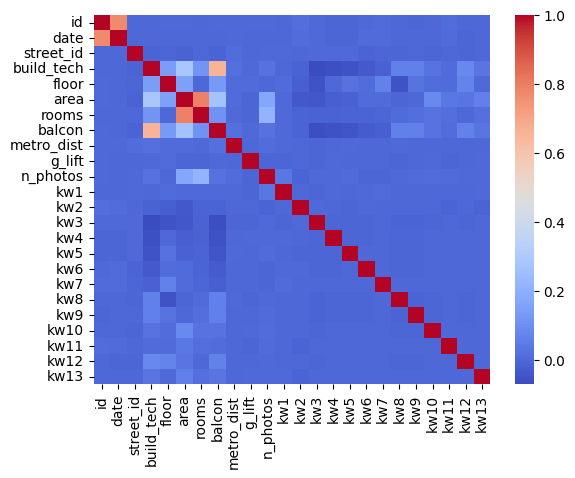

In [ ]:
sns.heatmap(dfTest_new.corr(), annot=False, cmap='coolwarm')
plt.show()

In [ ]:
dfTest_dropped = dfTest_new.drop(columns=['date', 'id', 'g_lift', 'kw1', 'kw3', 'kw4', 'kw5', 'kw6', 'kw7', 'kw8', 'kw9', 'kw11', 'kw12', 'kw13'])
dfTest_dropped

,street_id,build_tech,floor,area,rooms,balcon,metro_dist,n_photos,kw2,kw10
0,459,0.5,1,60,3,1,30.000000,4,0,0
1,344,1.0,10,52,2,1,22.081353,4,0,0
2,585,0.0,4,54,3,0,30.000000,0,0,0
3,494,0.5,2,52,2,1,25.000000,3,1,0
4,622,1.0,9,60,3,1,15.000000,1,1,0
...,...,...,...,...,...,...,...,...,...,...
99995,613,1.0,2,34,1,1,25.000000,2,1,0
99996,167,1.0,10,61,3,1,30.000000,4,1,0
99997,391,1.0,9,34,1,1,30.000000,3,1,0
99998,21,0.0,7,58,3,0,30.000000,3,0,0


In [ ]:
dfTest_new['street_id'].describe().apply("{0:.5f}".format)

count    100000.00000
mean        334.75843
std         193.83161
min           0.00000
25%         166.00000
50%         334.00000
75%         502.00000
max         671.00000
Name: street_id, dtype: object

In [ ]:
#scaler = StandardScaler()
#dfTest_dropped.iloc[:,0:-1] = scaler.fit_transform(dfTest_dropped.iloc[:,0:-1].to_numpy())
xTest = dfTest_new[['street_id', 'area', 'rooms', 'metro_dist', 'kw10', 'build_tech']]
yTest = regressor.predict(xTest)

In [ ]:
yTest = model_xgb.predict(xTest)

In [ ]:
yId = dfTest['id'].values.reshape(len(dfTest['id']), 1)
yTest = yTest.reshape(len(dfTest['id']), 1)
result = np.concatenate((yId, yTest), axis = 1)
np.savetxt("result.csv", result.astype(int), fmt='%i', delimiter=",", header="id,price", comments='')